# Speed loop

`coaxial.loop`'s chain, identified back out of its own run. No board.

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

Blocks on one bus: a ramp, a d-axis probe (torque-free, and the one thing that lets Ld out of a fit), the speed loop, the current loop, the machine. `run` records every slot; `identify` hands the run to `coaxial.sysid` and gets the constants back with their uncertainty.

In [2]:
import math
from coaxial.loop import Ramp, Probe, SpeedLoop, CurrentLoop, Machine, identify
from coaxial.motor import BENCH_MOTOR
from coaxial import inverter

TWO_PI = 2.0 * math.pi
motor = BENCH_MOTOR
print(motor)
vdc = 24.0
chain = (Ramp(top=300.0 * TWO_PI, rise=0.6)
         >> Probe(amps=1.0, hz=40.0)
         >> SpeedLoop(hz=8.0, limit=6.0, motor=motor)
         >> CurrentLoop(hz=1000.0, motor=motor, vdc=vdc)
         >> Machine(motor, vdc=vdc, noise=0.02, sub=4))
run = chain.run(seconds=1.4, dt=2.0 * inverter.TS)
print('samples', len(run['t']), ' top %.0f rad/s mech' % run['w'].max())

<stand-in bench motor ESTIMATED: R 0.0500 ohm, Ld 20.0 uH, Lq 30.0 uH, lambda 0.00500 Wb, 7 pole pairs, KV 158>


samples 35000  top 397 rad/s mech


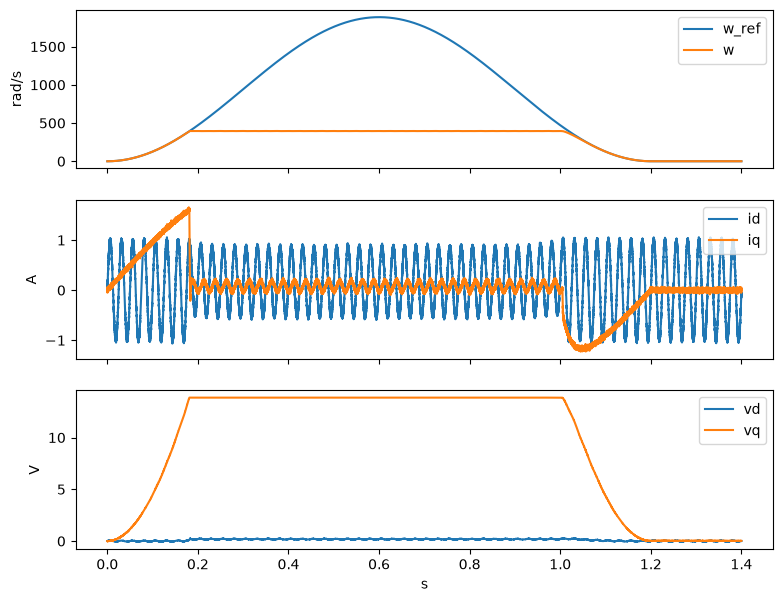

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(9, 7))
axes[0].plot(run['t'], run['w_ref'], label='w_ref')
axes[0].plot(run['t'], run['w'], label='w'); axes[0].set_ylabel('rad/s'); axes[0].legend()
axes[1].plot(run['t'], run['id'], label='id'); axes[1].plot(run['t'], run['iq'], label='iq')
axes[1].set_ylabel('A'); axes[1].legend()
axes[2].plot(run['t'], run['vd'], label='vd'); axes[2].plot(run['t'], run['vq'], label='vq')
axes[2].set_ylabel('V'); axes[2].set_xlabel('s'); axes[2].legend()
plt.show()

In [4]:
fit, got = identify(run, motor.poles)
print(fit)
print(fit.source)
print('condition %.2e  residual %.4f V' % (got['condition'], got['residual_v']))
for name, truth in (('r', motor.r), ('ld', motor.ld), ('lq', motor.lq), ('lam', motor.lam)):
    print('%-4s truth %.5g  fit %.5g  %+.1f %%  uncertainty %.1f %%  trusted %s'
          % (name, truth, got[name], 100.0 * (got[name] / truth - 1.0),
             100.0 * got['uncertainty'][name], got['trusted'][name]))

<identified ESTIMATED: R 0.0816 ohm, Ld 18.7 uH, Lq -2.7 uH, lambda 0.00500 Wb, 7 pole pairs, KV 158>
least squares over a simulated run - 35000 samples, condition 7.5e-01
condition 7.48e-01  residual 0.0990 V
r    truth 0.05  fit 0.08163  +63.3 %  uncertainty 0.8 %  trusted True
ld   truth 2e-05  fit 1.8732e-05  -6.3 %  uncertainty 2.3 %  trusted True
lq   truth 3e-05  fit -2.6631e-06  -108.9 %  uncertainty 21.4 %  trusted False
lam  truth 0.005  fit 0.004996  -0.1 %  uncertainty 0.0 %  trusted True


Without the probe the inductance column is R's: the same run, identified with `did/dt` unexcited.

In [5]:
still = (Ramp(top=300.0 * TWO_PI, rise=0.6)
         >> SpeedLoop(hz=8.0, limit=6.0, motor=motor)
         >> CurrentLoop(hz=1000.0, motor=motor, vdc=vdc)
         >> Machine(motor, vdc=vdc, noise=0.02, sub=4))
run2 = still.run(seconds=1.4, dt=2.0 * inverter.TS)
_, got2 = identify(run2, motor.poles)
for name in ('r', 'ld', 'lq', 'lam'):
    print('%-4s fit %.5g  uncertainty %.1f %%  trusted %s'
          % (name, got2[name], 100.0 * got2['uncertainty'][name], got2['trusted'][name]))

r    fit 0.0046473  uncertainty 24.1 %  trusted False
ld   fit 5.2515e-06  uncertainty 24.4 %  trusted False
lq   fit -3.3285e-06  uncertainty 17.4 %  trusted False
lam  fit 0.004997  uncertainty 0.0 %  trusted True


## Conclusions

In [6]:
print('%-6s %-12s %-12s %-12s %-12s' % ('', 'truth', 'with probe', 'no probe', 'probe cost'))
for name, truth in (('r', motor.r), ('ld', motor.ld), ('lq', motor.lq), ('lam', motor.lam)):
    print('%-6s %-12.5g %-12.5g %-12.5g %+.1f %% -> %+.1f %%'
          % (name, truth, got[name], got2[name],
             100.0 * (got[name] / truth - 1.0), 100.0 * (got2[name] / truth - 1.0)))
print()
print('condition   with probe %.2e, without %.2e' % (got['condition'], got2['condition']))
print('trusted     with probe %s' % [n for n in ('r', 'ld', 'lq', 'lam') if got['trusted'][n]])
print('            without    %s' % [n for n in ('r', 'ld', 'lq', 'lam') if got2['trusted'][n]])

       truth        with probe   no probe     probe cost  
r      0.05         0.08163      0.0046473    +63.3 % -> -90.7 %
ld     2e-05        1.8732e-05   5.2515e-06   -6.3 % -> -73.7 %
lq     3e-05        -2.6631e-06  -3.3285e-06  -108.9 % -> -111.1 %
lam    0.005        0.004996     0.004997     -0.1 % -> -0.1 %

condition   with probe 7.48e-01, without 6.08e-01
trusted     with probe ['r', 'ld', 'lam']
            without    ['lam']


Two equations a sample, stacked; the columns are R, Ld, Lq and lambda, and each needs its own excitation. Without `did/dt` the inductance column is R's, which is why the probe is in the chain: torque-free, so the speed loop never sees it, and the one thing that lets Ld out of a fit.

The per-parameter standard error says which column the run excited; one number for the whole fit does not. A V/f ramp once identified R to 0.4 %, Ld to 1.4 %, lambda to 0.1 % and **Lq to minus 73** - iq barely moved, so `Lq did/dt` had no excitation and `omega Lq iq` went collinear with lambda. The global condition was 6.5e-2 and said nothing.

Two alignment facts sit behind the numbers, both found by the fit reading wrong. The bus is published before the period advances, so the loops run one period behind the machine as the firmware's pipeline does; publishing after read r at +17 % and Lq at -4 %. And the vector is aimed half a period of angle ahead, being held in the stator frame while the rotor turns through it; without that r came out at -218 % of itself at 9000 rad/s.